In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("network_data/Train_data.csv")

In [3]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
df.shape

(25192, 42)

In [5]:
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [6]:
df['class'].value_counts()

class
normal     13449
anomaly    11743
Name: count, dtype: int64

### Potential Approaches

* The above Autoencoder trains on all labels, which is not what we want. So train it only on normal classes
* Try VAEs
* Create API to receive logs, run it in the AE, and return anomalous data points in some form
* Create some charts that are relevant to show which are updated as new data keeps on coming. So, the API has memory of what data it encountered.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

import torch.nn as nn

# Preprocessing
# Convert categorical variables to numeric
categorical_columns = ['protocol_type', 'service', 'flag', 'class']
le_dict = {}
for column in categorical_columns:
    le_dict[column] = LabelEncoder()
    df[column] = le_dict[column].fit_transform(df[column])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((20153, 42), (5039, 42))

In [9]:
# Filter data points with 'normal' label
normal_df = X_train[X_train['class'] == int(le_dict['class'].transform(['normal']))]
# print(f"Number of normal data points: {len(normal_df)}")
# print(f"Percentage of normal data points: {(len(normal_df) / len(df)) * 100:.2f}%")
normal_df.drop('class', axis=1, inplace=True)

# Scale numerical features
scaler = StandardScaler()
X = scaler.fit_transform(normal_df)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)

# Create dataset and dataloader
class NetworkDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

# Define the autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim=41):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Create dataset and dataloader
dataset = NetworkDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Initialize model, loss function, and optimizer
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    total_loss = 0
    for batch in dataloader:
        # Forward pass
        output = model(batch)
        loss = criterion(output, batch)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Print epoch statistics
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.6f}')

C:\Users\Asus\AppData\Local\Temp\ipykernel_14820\3277820221.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  normal_df = X_train[X_train['class'] == int(le_dict['class'].transform(['normal']))]
C:\Users\Asus\AppData\Local\Temp\ipykernel_14820\3277820221.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_df.drop('class', axis=1, inplace=True)


Epoch [1/100], Loss: 0.853262
Epoch [2/100], Loss: 0.632143
Epoch [3/100], Loss: 0.512646
Epoch [4/100], Loss: 0.425351
Epoch [5/100], Loss: 0.385478
Epoch [6/100], Loss: 0.356841
Epoch [7/100], Loss: 0.335299
Epoch [8/100], Loss: 0.322949
Epoch [9/100], Loss: 0.316441
Epoch [10/100], Loss: 0.299523
Epoch [11/100], Loss: 0.282997
Epoch [12/100], Loss: 0.275331
Epoch [13/100], Loss: 0.265454
Epoch [14/100], Loss: 0.258749
Epoch [15/100], Loss: 0.253054
Epoch [16/100], Loss: 0.240224
Epoch [17/100], Loss: 0.233426
Epoch [18/100], Loss: 0.225958
Epoch [19/100], Loss: 0.225925
Epoch [20/100], Loss: 0.217396
Epoch [21/100], Loss: 0.207184
Epoch [22/100], Loss: 0.206646
Epoch [23/100], Loss: 0.199056
Epoch [24/100], Loss: 0.199601
Epoch [25/100], Loss: 0.188747
Epoch [26/100], Loss: 0.185894
Epoch [27/100], Loss: 0.183120
Epoch [28/100], Loss: 0.179807
Epoch [29/100], Loss: 0.178147
Epoch [30/100], Loss: 0.174296
Epoch [31/100], Loss: 0.168932
Epoch [32/100], Loss: 0.170901
Epoch [33/100], L

In [10]:
# Get a sample batch from the dataloader
sample_batch = next(iter(dataloader))

# Get the reconstructed output
model.eval()  # Set to evaluation mode
with torch.no_grad():
    reconstructed = model(sample_batch)

# Calculate reconstruction error
reconstruction_error = torch.mean((sample_batch - reconstructed) ** 2, dim=1)

# Print some statistics
print("Reconstruction error statistics:")
print(f"Mean: {reconstruction_error.mean():.6f}")
print(f"Std: {reconstruction_error.std():.6f}")
print(f"Min: {reconstruction_error.min():.6f}")
print(f"Max: {reconstruction_error.max():.6f}")

# Compare first few original and reconstructed samples
print("\nFirst few features of original vs reconstructed:")
print("Original:", sample_batch[0][:5].numpy())
print("Reconstructed:", reconstructed[0][:5].numpy())

Reconstruction error statistics:
Mean: 0.076807
Std: 0.327763
Min: 0.000675
Max: 2.812452

First few features of original vs reconstructed:
Original: [-0.13697262 -0.3992486  -0.2475142   0.23886739 -0.06850767]
Reconstructed: [-0.09015805 -0.39515078 -0.3055621   0.20343655 -0.10779015]


In [11]:
# Get a sample of the original dataframe that includes both normal and anomalous data
# First get non-normal data points
anomalous_df = X_test[X_test['class'] != int(le_dict['class'].transform(['normal']))].copy()
anomalous_df.drop('class', axis=1, inplace=True)

# Scale the anomalous data using the same scaler
X_anomalous = scaler.transform(anomalous_df)
X_anomalous_tensor = torch.FloatTensor(X_anomalous)

# Get reconstruction error for both normal and anomalous data
model.eval()
with torch.no_grad():
    # Get reconstruction error for normal data
    normal_reconstructed = model(X_tensor)
    normal_reconstruction_error = torch.mean((X_tensor - normal_reconstructed) ** 2, dim=1)
    
    # Get reconstruction error for anomalous data
    anomalous_reconstructed = model(X_anomalous_tensor)
    anomalous_reconstruction_error = torch.mean((X_anomalous_tensor - anomalous_reconstructed) ** 2, dim=1)

# Calculate and print statistics
print("Normal data reconstruction error:")
print(f"Mean: {normal_reconstruction_error.mean():.6f}")
print(f"Std: {normal_reconstruction_error.std():.6f}")
print(f"Max: {normal_reconstruction_error.max():.6f}")
print(f"\nAnomalous data reconstruction error:")
print(f"Mean: {anomalous_reconstruction_error.mean():.6f}")
print(f"Std: {anomalous_reconstruction_error.std():.6f}")
print(f"Max: {anomalous_reconstruction_error.max():.6f}")

Normal data reconstruction error:
Mean: 0.080173
Std: 0.374456
Max: 20.263779

Anomalous data reconstruction error:
Mean: 1.456173
Std: 1.016536
Max: 12.164651


C:\Users\Asus\AppData\Local\Temp\ipykernel_14820\631539784.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anomalous_df = X_test[X_test['class'] != int(le_dict['class'].transform(['normal']))].copy()


In [12]:
normal_class_label = int(le_dict['class'].transform(['normal']))
print(f"\nClass label for normal data: {normal_class_label}")


Class label for normal data: 1


C:\Users\Asus\AppData\Local\Temp\ipykernel_14820\1850172230.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  normal_class_label = int(le_dict['class'].transform(['normal']))


In [26]:
threshold_95 = np.percentile(normal_reconstruction_error, 95)
threshold_99 = np.percentile(normal_reconstruction_error, 99)
threshold_90 = np.percentile(normal_reconstruction_error, 90)

print(f"\n90th percentile threshold: {threshold_90:.6f}")
print(f"95th percentile threshold: {threshold_95:.6f}")
print(f"99th percentile threshold: {threshold_99:.6f}")

# Get predictions
test_df = X_test.drop('class', axis=1)
X_test_scaled = scaler.transform(test_df)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# Get reconstruction error for test data
model.eval()
with torch.no_grad():
	test_reconstructed = model(X_test_tensor)
	test_reconstruction_error = torch.mean((X_test_tensor - test_reconstructed) ** 2, dim=1)

# Make predictions based on threshold
anomalous_class_label = 0  # Label for anomalous class
predictions = torch.ones(len(X_test))
predictions[test_reconstruction_error > threshold_90] = anomalous_class_label

# Calculate recall for the anomalous class
true_labels = torch.tensor(X_test['class'].values)  # Ground truth labels

# True Positive (TP): Correctly identified anomalous samples
true_positive = torch.sum(predictions[true_labels == anomalous_class_label] == 0).item()

# False Negative (FN): Anomalous samples incorrectly classified as normal
false_negative = torch.sum(predictions[true_labels == anomalous_class_label] == 1).item()

# Recall for anomalous class
recall = true_positive / (true_positive + false_negative)
print(f"Anomalous Recall: {recall:.6f}")

# Calculate precision for the anomalous class
# False Positive (FP): Normal samples incorrectly classified as anomalous
false_positive = torch.sum(predictions[true_labels == normal_class_label] == 0).item()

# Precision for anomalous class
precision = true_positive / (true_positive + false_positive)
print(f"Anomalous Precision: {precision:.6f}")



90th percentile threshold: 0.174375
95th percentile threshold: 0.296481
99th percentile threshold: 1.144493
Anomalous Recall: 0.966173
Anomalous Precision: 0.904234


In [27]:
print(true_labels)
print(predictions)
print(true_positive)
print(false_negative)

tensor([0, 1, 0,  ..., 1, 1, 1], dtype=torch.int32)
tensor([0., 1., 0.,  ..., 1., 1., 1.])
2285
80


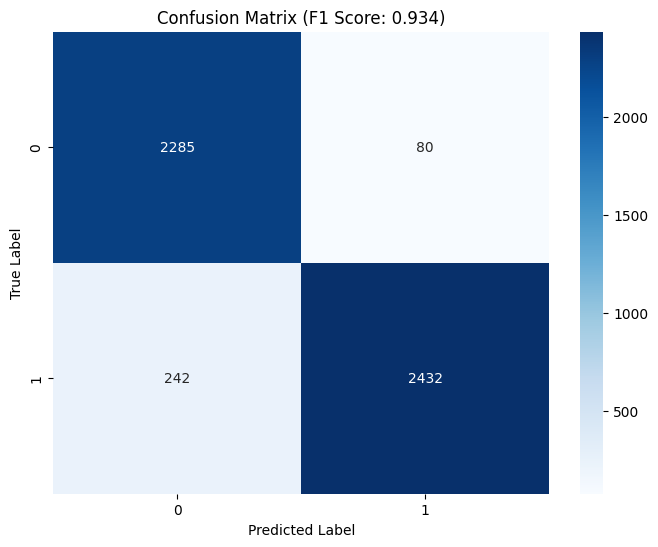

In [28]:
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate F1 score
f1 = f1_score(true_labels, predictions, pos_label=anomalous_class_label)

# Create confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (F1 Score: {f1:.3f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()